# Encoding Accuracy Brain Plots

This notebook maps saved per-parcel or per-voxel encoding accuracy vectors back onto each subject's Schaefer atlas volume and plots them with Nilearn. The saved accuracy vectors are Pearson correlations from `RunningPearson`, so the default plot is signed and uses a symmetric diverging color scale.

In [9]:
%matplotlib inline

from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
import matplotlib.font_manager as fm
import nibabel as nib
from nilearn import plotting
import seaborn as sns

warnings.filterwarnings("ignore")

font_dir = "/engram/nklab/pf2477/other/font/"
if os.path.isdir(font_dir):
    for font in os.listdir(font_dir):
        if font.startswith("Times New Roman"):
            print("Adding font:", font)
            fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="white", font="Times New Roman")


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if path.name == "multimodal_encoder" and (path / "ckpt").exists():
            return path
    fallback = Path("/engram/nklab/pf2477/multimodal_encoder")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not locate the multimodal_encoder repository root.")


REPO_ROOT = find_repo_root()
CKPT_ROOT = REPO_ROOT / "ckpt"
FIGURE_ROOT = REPO_ROOT / "notebooks" / "figures" / "encoding_acc"
TABLE_ROOT = REPO_ROOT / "notebooks" / "tables" / "encoding_acc"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

FMRI_ROOT_CANDIDATES = [
    Path("/engram/nklab/datasets/algonauts_2025.competitors/fmri"),
    Path("/Volumes/kriegeskorte-locker/datasets/algonauts_2025.competitors/fmri"),
    Path("/Volumes/kriegeskorte-locker/pf2477/datasets/algonauts_2025.competitors/fmri"),
]
FMRI_ROOT = next((path for path in FMRI_ROOT_CANDIDATES if path.exists()), FMRI_ROOT_CANDIDATES[0])

SUBJECT_ATLAS = {
    1: "sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    2: "sub-02/atlas/sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    3: "sub-03/atlas/sub-03_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    5: "sub-05/atlas/sub-05_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
}

print("repo:", REPO_ROOT)
print("checkpoint root:", CKPT_ROOT)
print("fMRI root:", FMRI_ROOT)

Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf
repo: /engram/nklab/pf2477/multimodal_encoder
checkpoint root: /engram/nklab/pf2477/multimodal_encoder/ckpt
fMRI root: /engram/nklab/datasets/algonauts_2025.competitors/fmri


## Runs To Plot

Register each available checkpoint once, then reuse the same plotting helpers for parcel-level and voxel-level encoding maps.


In [10]:
CKPT_RUNS = [
    {"run_name": "04-07-2026-16-09", "subject": 1, "readout_res": "parcels", "split": "test"},
    {"run_name": "04-07-2026-16-13", "subject": 2, "readout_res": "parcels", "split": "test"},
    {"run_name": "04-08-2026-00-52", "subject": 3, "readout_res": "parcels", "split": "test"},
    {"run_name": "04-08-2026-00-55", "subject": 5, "readout_res": "parcels", "split": "test"},
    {"run_name": "04-08-2026-23-43", "subject": 1, "readout_res": "voxels", "split": "test"},
    {"run_name": "04-08-2026-23-48", "subject": 2, "readout_res": "voxels", "split": "test"},
    {"run_name": "04-08-2026-23-57", "subject": 3, "readout_res": "voxels", "split": "test"},
    {"run_name": "04-12-2026-19-49", "subject": 5, "readout_res": "voxels", "split": "test"},

#     {"run_name": "04-18-2026-01-08", "subject": 1, "readout_res": "parcels", "split": "test"},
#     {"run_name": "04-18-2026-01-14", "subject": 2, "readout_res": "parcels", "split": "test"},
#     {"run_name": "04-18-2026-22-20", "subject": 3, "readout_res": "parcels", "split": "test"},
#     {"run_name": "04-18-2026-22-22",  "subject": 5, "readout_res": "parcels", "split": "test"},
#     {"run_name": "04-19-2026-02-08", "subject": 1, "readout_res": "voxels", "split": "test"},
#     {"run_name": "04-19-2026-02-10", "subject": 2, "readout_res": "voxels", "split": "test"},
#     {"run_name": "04-20-2026-00-29", "subject": 3, "readout_res": "voxels", "split": "test"},
#     {"run_name": "04-20-2026-00-29",  "subject": 5, "readout_res": "voxels", "split": "test"},
]


def accuracy_path(subject, run_name, readout_res, split="test", normalized=True):
    if normalized and readout_res == "parcels":
        filename = f"{split}_{readout_res}_normalized_acc.npy"
    else:
        filename = f"{split}_{readout_res}_acc.npy"
    return CKPT_ROOT / str(subject) / run_name / filename


def load_accuracy_vector(subject, run_name, readout_res, split="test", normalized=True):
    path = accuracy_path(subject, run_name, readout_res, split, normalized)
    if not path.exists():
        raise FileNotFoundError(path)
    values = np.load(path).astype(np.float32, copy=False)
    if values.ndim != 1:
        raise ValueError(f"Expected a 1D accuracy vector, got {values.shape} at {path}")
    if readout_res == "parcels" and values.shape[0] != 1000:
        raise ValueError(f"Parcel accuracy should have length 1000, got {values.shape[0]} at {path}")
    return values, path


def summarize_accuracy_vector(values):
    finite = values[np.isfinite(values)]
    return {
        "n": int(values.size),
        "mean_r": float(np.nanmean(values)),
        "median_r": float(np.nanmedian(values)),
        "max_r": float(np.nanmax(values)),
        "min_r": float(np.nanmin(values)),
        "positive_fraction": float(np.mean(finite > 0.0)) if finite.size else np.nan,
    }


def collect_accuracy_data(run_specs, normalized=True):
    rows = []
    items = []
    for spec in run_specs:
        run_name = spec["run_name"]
        subject = spec["subject"]
        readout_res = spec["readout_res"]
        split = spec.get("split", "test")
        values, path = load_accuracy_vector(subject, run_name, readout_res, split, normalized=normalized)
        item = {**spec, "values": values, "path": path}
        items.append(item)
        rows.append({
            "subject": subject,
            "run_name": run_name,
            "readout_res": readout_res,
            "split": split,
            "path": str(path),
            **summarize_accuracy_vector(values),
        })
    summary_df = pd.DataFrame(rows).sort_values(["readout_res", "subject", "run_name"]).reset_index(drop=True)
    return items, summary_df


acc_items, summary_df = collect_accuracy_data(CKPT_RUNS, normalized=False)
display(summary_df)


,subject,run_name,readout_res,split,path,n,mean_r,median_r,max_r,min_r,positive_fraction
0,1,04-07-2026-16-09,parcels,test,/engram/nklab/pf2477/multimodal_encoder/ckpt/1...,1000,0.180256,0.158811,0.663931,-0.036716,0.988000
1,2,04-07-2026-16-13,parcels,test,/engram/nklab/pf2477/multimodal_encoder/ckpt/2...,1000,0.167164,0.150641,0.644709,-0.027948,0.994000
2,3,04-08-2026-00-52,parcels,test,/engram/nklab/pf2477/multimodal_encoder/ckpt/3...,1000,0.185232,0.152909,0.686616,-0.006463,0.996000
3,5,04-08-2026-00-55,parcels,test,/engram/nklab/pf2477/multimodal_encoder/ckpt/5...,1000,0.154915,0.132252,0.611757,-0.010453,0.995000
4,1,04-08-2026-23-43,voxels,test,/engram/nklab/pf2477/multimodal_encoder/ckpt/1...,122721,0.132054,0.111711,0.689011,-0.177804,0.969329
5,2,04-08-2026-23-48,voxels,test,/engram/nklab/pf2477/multimodal_encoder/ckpt/2...,119282,0.123081,0.102974,0.667048,-0.135037,0.973475
6,3,04-08-2026-23-57,voxels,test,/engram/nklab/pf2477/multimodal_encoder/ckpt/3...,123035,0.145109,0.117806,0.703427,-0.169450,0.980111
7,5,04-12-2026-19-49,voxels,test,/engram/nklab/pf2477/multimodal_encoder/ckpt/5...,122978,0.114153,0.094337,0.620598,-0.204119,0.979988


## Brain Mapping Helpers

For parcel vectors, parcel `i` is assigned to Schaefer label `i + 1`. For voxel vectors, values are placed into voxels where `epi_mask & parcellation != 0`; this matches the dataset's valid voxel filtering.

In [19]:
def load_subject_atlas(subject):
    atlas_path = FMRI_ROOT / SUBJECT_ATLAS[subject]
    if not atlas_path.exists():
        raise FileNotFoundError(atlas_path)
    img = nib.load(atlas_path)
    data = np.asarray(img.dataobj, dtype=np.int32)
    return img, data, atlas_path


def parcel_accuracy_to_img(values, subject):
    values = np.asarray(values, dtype=np.float32)
    if values.shape != (1000,):
        raise ValueError(f"Expected parcel vector shape (1000,), got {values.shape}")
    atlas_img, atlas_data, _ = load_subject_atlas(subject)
    out = np.full(atlas_data.shape, np.nan, dtype=np.float32)
    for parcel_id in range(1, 1001):
        out[atlas_data == parcel_id] = values[parcel_id - 1]
    return nib.Nifti1Image(out, affine=atlas_img.affine, header=atlas_img.header)


def voxel_reference_candidates(subject):
    rel = Path(f"Schaefer18_1000Parcels7Networks/sub-{subject:02}/func")
    return [
        Path("/engram/nklab/eh2976/cneuromod_extract_tseries/outputs/movie10") / rel,
        Path("/Volumes/kriegeskorte-locker/eh2976/cneuromod_extract_tseries/outputs/movie10") / rel,
        Path("/Volumes/kriegeskorte-locker/pf2477/cneuromod_extract_tseries/outputs/movie10") / rel,
    ]


def load_voxel_reference(subject):
    for base_dir in voxel_reference_candidates(subject):
        parcellation_path = base_dir / "schaefer_parcellation.npy"
        epi_mask_path = base_dir / "epi_mask.npy"
        if parcellation_path.exists() and epi_mask_path.exists():
            parcellation = np.load(parcellation_path)
            epi_mask = np.load(epi_mask_path).astype(bool)
            atlas_img, _, _ = load_subject_atlas(subject)
            return atlas_img, parcellation, epi_mask, base_dir
    raise FileNotFoundError(
        "Could not find schaefer_parcellation.npy and epi_mask.npy for voxel plotting. "
        f"Checked: {[str(p) for p in voxel_reference_candidates(subject)]}"
    )


def voxel_accuracy_to_img(values, subject):
    values = np.asarray(values, dtype=np.float32)
    atlas_img, parcellation, epi_mask, _ = load_voxel_reference(subject)
    valid_mask = epi_mask.astype(bool) & (parcellation != 0)
    if values.shape[0] != int(valid_mask.sum()):
        raise ValueError(
            f"Voxel vector length {values.shape[0]} does not match valid mask count {int(valid_mask.sum())}."
        )
    out = np.full(parcellation.shape, np.nan, dtype=np.float32)
    out[valid_mask] = values
    return nib.Nifti1Image(out, affine=atlas_img.affine, header=atlas_img.header)


def accuracy_to_img(values, subject, readout_res):
    if readout_res == "parcels":
        return parcel_accuracy_to_img(values, subject)
    if readout_res == "voxels":
        return voxel_accuracy_to_img(values, subject)
    raise ValueError(f"Unsupported readout_res: {readout_res}")


def filter_accuracy_items(items, readout_res=None, split="test"):
    filtered = [
        item for item in items
        if (readout_res is None or item["readout_res"] == readout_res)
        and item.get("split", "test") == split
    ]
    return sorted(filtered, key=lambda item: (item["readout_res"], item["subject"], item["run_name"]))


def make_cbar_ticks(vmin, vmax, step=0.1, positive_only=False):
    start = np.ceil(vmin / step) * step
    stop = np.floor(vmax / step) * step
    ticks = np.round(np.arange(start, stop + (step * 0.5), step), 1)
    if positive_only:
        ticks = ticks[ticks > 0]
    if ticks.size == 0:
        ticks = np.array([round(vmax, 1)], dtype=np.float32)
    return ticks


def plot_accuracy_img(
    img,
    data=None,
    title=None,
    out_file=None,
    positive_only=False,
    display_mode="lyrz",
    cmap=None,
):
    plot_data = np.asarray(img.dataobj if data is None else data, dtype=np.float32).copy()
    if positive_only:
        plot_data = np.where(np.isfinite(plot_data), np.maximum(plot_data, 0.0), np.nan)

    plot_img = nib.Nifti1Image(plot_data, affine=img.affine, header=img.header)
    finite = plot_data[np.isfinite(plot_data)]
    if finite.size == 0:
        raise ValueError("No finite accuracy values available for plotting.")

    if positive_only:
        vmin = 0.0
        # vmax = 0.6 #max(float(np.nanpercentile(finite, 99)), 1e-6)
        vmax = max(float(np.nanpercentile(finite, 99)), 1e-6)
        threshold = 0.0
        symmetric_cbar = False
        cmap = cmap or "viridis"
    else:
        vmax = max(float(np.nanpercentile(np.abs(finite), 98)), 1e-6)
        vmin = -vmax
        threshold = None
        symmetric_cbar = True
        cmap = cmap or "coolwarm"

    fig = plt.figure(figsize=(12, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        plot_img,
        display_mode=display_mode,
        title=title,
        cmap=cmap,
        colorbar=True,
        plot_abs=False,
        threshold=threshold,
        vmin=vmin,
        vmax=vmax,
        symmetric_cbar=symmetric_cbar,
        black_bg=False,
        figure=fig,
    )

    cbar = getattr(display, "_cbar", None)
    if cbar is not None:
        ticks = make_cbar_ticks(vmin, vmax, step=0.1, positive_only=positive_only)
        cbar.set_ticks(ticks)
        cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        cbar.set_label("Pearson Correlation", rotation=90, labelpad=16, fontsize=28)
        cbar.ax.tick_params(labelsize=24)

    if out_file is not None:
        out_file = Path(out_file)
        out_file.parent.mkdir(parents=True, exist_ok=True)
        fig.canvas.draw()
        fig.savefig(str(out_file), dpi=300, bbox_inches="tight")
        print("saved:", out_file)

    plotting.show()
    return display


def plot_encoding_accuracy(
    values,
    subject,
    readout_res,
    title=None,
    out_file=None,
    positive_only=False,
    display_mode="lyrz",
    cmap=None,
):
    img = accuracy_to_img(values, subject, readout_res)
    return plot_accuracy_img(
        img,
        title=title,
        out_file=out_file,
        positive_only=positive_only,
        display_mode=display_mode,
        cmap=cmap,
    )


def summarize_group_parcels(items):
    if not items:
        raise ValueError("No parcel runs available for grouping.")

    parcel_acc = np.stack([item["values"] for item in items], axis=0)
    subjects = np.array([item["subject"] for item in items], dtype=np.int32)
    clipped = np.clip(parcel_acc, -0.999999, 0.999999)
    mean_r = np.nanmean(parcel_acc, axis=0).astype(np.float32)
    fisher_mean_r = np.tanh(np.nanmean(np.arctanh(clipped), axis=0)).astype(np.float32)
    if parcel_acc.shape[0] > 1:
        sem_r = (np.nanstd(parcel_acc, axis=0, ddof=1) / np.sqrt(parcel_acc.shape[0])).astype(np.float32)
    else:
        sem_r = np.full(parcel_acc.shape[1], np.nan, dtype=np.float32)
    n_subjects = np.sum(np.isfinite(parcel_acc), axis=0).astype(np.int32)

    group_df = pd.DataFrame({
        "parcel_id": np.arange(1, parcel_acc.shape[1] + 1),
        "mean_r": mean_r,
        "fisher_mean_r": fisher_mean_r,
        "sem_r": sem_r,
        "n_subjects": n_subjects,
    })
    for subject, values in zip(subjects, parcel_acc):
        group_df[f"sub-{subject:02d}_r"] = values

    return fisher_mean_r, group_df


def summarize_group_voxels(items, shared_only=True):
    if not items:
        raise ValueError("No voxel runs available for grouping.")

    img_stack = []
    ref_img = None
    for item in items:
        img = voxel_accuracy_to_img(item["values"], item["subject"])
        if ref_img is None:
            ref_img = img
        img_stack.append(np.asarray(img.dataobj, dtype=np.float32))

    stack = np.stack(img_stack, axis=0)
    group_data = np.nanmean(stack, axis=0).astype(np.float32)
    n_subjects = np.sum(np.isfinite(stack), axis=0).astype(np.int32)
    if shared_only:
        group_data[n_subjects < len(items)] = np.nan

    group_img = nib.Nifti1Image(group_data, affine=ref_img.affine, header=ref_img.header)
    return group_img, group_data, n_subjects


def voxel_values_to_parcel_means(values, subject, num_parcels=1000):
    values = np.asarray(values, dtype=np.float32)
    _, parcellation, epi_mask, _ = load_voxel_reference(subject)
    valid_mask = epi_mask.astype(bool) & (parcellation != 0)
    labels = np.asarray(parcellation[valid_mask], dtype=np.int64)
    if values.shape[0] != labels.shape[0]:
        raise ValueError(
            f"Voxel vector length {values.shape[0]} does not match labeled voxel count {labels.shape[0]}."
        )

    parcel_index = labels - 1
    parcel_sums = np.bincount(parcel_index, weights=values, minlength=num_parcels)
    parcel_counts = np.bincount(parcel_index, minlength=num_parcels)
    parcel_means = np.full(num_parcels, np.nan, dtype=np.float32)
    has_voxels = parcel_counts > 0
    parcel_means[has_voxels] = (parcel_sums[has_voxels] / parcel_counts[has_voxels]).astype(np.float32)
    return parcel_means, parcel_counts.astype(np.int32)


def plot_individual_encoding_acc(
    items,
    readout_res,
    split="test",
    positive_only=True,
    display_mode="lyrz",
    cmap="inferno",
    save=False,
):
    selected_items = filter_accuracy_items(items, readout_res=readout_res, split=split)
    if not selected_items:
        raise ValueError(f"No runs found for {readout_res=} and {split=}.")

    for item in selected_items:
        subject = item["subject"]
        run_name = item["run_name"]
        title = f"sub-{subject:02d} {split} {readout_res} encoding accuracy"
        stem = f"sub-{subject:02d}_{run_name}_{split}_{readout_res}_encoding_acc"
        out_file = FIGURE_ROOT / f"{stem}_positive_glass.pdf" if save else None
        print(f"Plotting {stem}...")
        plot_encoding_accuracy(
            item["values"],
            subject=subject,
            readout_res=readout_res,
            # title=title,
            out_file=out_file,
            positive_only=positive_only,
            display_mode=display_mode,
            cmap=cmap,
        )

    return selected_items


def plot_overall_encoding_acc(
    items,
    readout_res,
    split="test",
    positive_only=True,
    display_mode="lyrz",
    cmap="inferno",
    reference_subject=1,
    shared_only=True,
    save=False,
    backbones="dino_whisper_llama",
):
    selected_items = filter_accuracy_items(items, readout_res=readout_res, split=split)
    if not selected_items:
        raise ValueError(f"No runs found for {readout_res=} and {split=}.")

    if readout_res == "parcels":
        fisher_mean_r, group_df = summarize_group_parcels(selected_items)
        group_df.to_csv(TABLE_ROOT / f"group_{split}_{readout_res}_encoding_accuracy.csv", index=False)
        display(group_df.head())
        display(group_df[["mean_r", "fisher_mean_r", "sem_r"]].describe())
        out_file = FIGURE_ROOT / f"encoding_acc_{readout_res}_{backbones}.pdf" if save else None
        plot_encoding_accuracy(
            fisher_mean_r,
            subject=reference_subject,
            readout_res=readout_res,
            # title=f"group {split} {readout_res} encoding accuracy",
            out_file=out_file,
            positive_only=positive_only,
            display_mode=display_mode,
            cmap=cmap,
        )
        return group_df

    if readout_res == "voxels":
        group_img, group_data, n_subjects = summarize_group_voxels(selected_items, shared_only=shared_only)
        out_file = FIGURE_ROOT / f"encoding_acc_{readout_res}_{backbones}.pdf" if save else None
        plot_accuracy_img(
            group_img,
            data=group_data,
            # title=f"group {split} {readout_res} encoding accuracy",
            out_file=out_file,
            positive_only=positive_only,
            display_mode=display_mode,
            cmap=cmap,
        )
        return {
            "n_subjects": n_subjects,
            "shared_only": shared_only,
            "subjects": [item["subject"] for item in selected_items],
        }

    raise ValueError(f"Unsupported readout_res: {readout_res}")


## Plot Individual And Overall Encoding Accuracy

Use the same entry points for parcels and voxels. `plot_individual_encoding_acc(...)` handles per-subject maps, and `plot_overall_encoding_acc(...)` handles the across-subject average.


In [12]:
# for readout_res in ("parcels", "voxels"):
#     available = filter_accuracy_items(acc_items, readout_res=readout_res, split="test")
#     if not available:
#         continue
#     print(f"\nIndividual {readout_res} encoding accuracy")
#     plot_individual_encoding_acc(
#         acc_items,
#         readout_res=readout_res,
#         split="test",
#         positive_only=True,
#         cmap="inferno",
#         save=True,
#     )



Overall parcels encoding accuracy


,parcel_id,mean_r,fisher_mean_r,sem_r,n_subjects,sub-01_r,sub-02_r,sub-03_r,sub-05_r
0,1,0.115830,0.115842,0.005953,4,0.130523,0.106769,0.105551,0.120476
1,2,0.210742,0.211021,0.020672,4,0.245344,0.163279,0.245414,0.188930
2,3,0.219876,0.221197,0.042692,4,0.255960,0.141482,0.323275,0.158786
3,4,0.284631,0.286022,0.038636,4,0.308135,0.190757,0.374918,0.264716
4,5,0.248878,0.250647,0.044018,4,0.221606,0.180042,0.378021,0.215845


,mean_r,fisher_mean_r,sem_r
count,1000.000000,1000.000000,1000.000000
mean,0.171892,0.172377,0.020298
std,0.106574,0.107200,0.013214
min,0.000921,0.000920,0.001997
25%,0.097304,0.097311,0.010618
50%,0.152594,0.152870,0.016993
75%,0.219030,0.219846,0.026471
max,0.626109,0.627526,0.089465


saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/encoding_acc_parcels_dino_whisper_llama.pdf


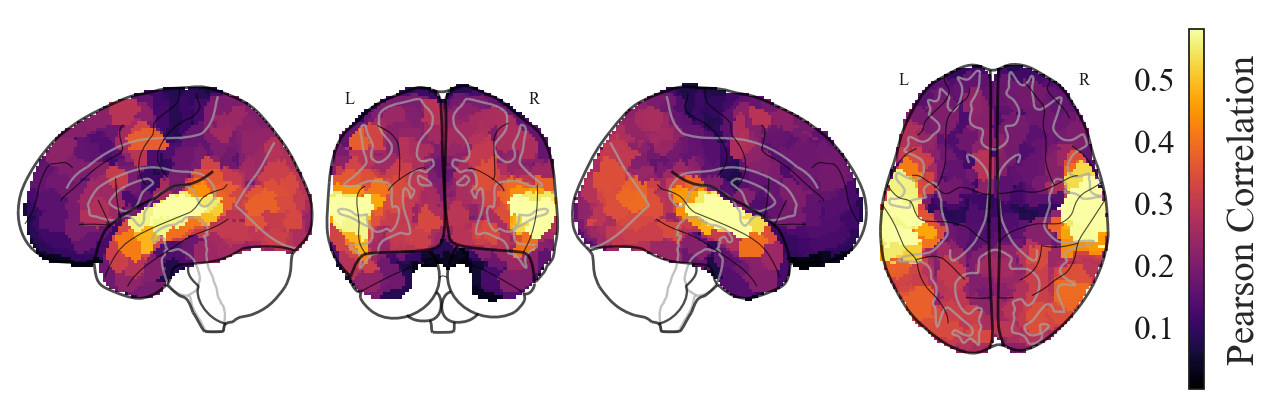


Overall voxels encoding accuracy
saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/encoding_acc_voxels_dino_whisper_llama.pdf


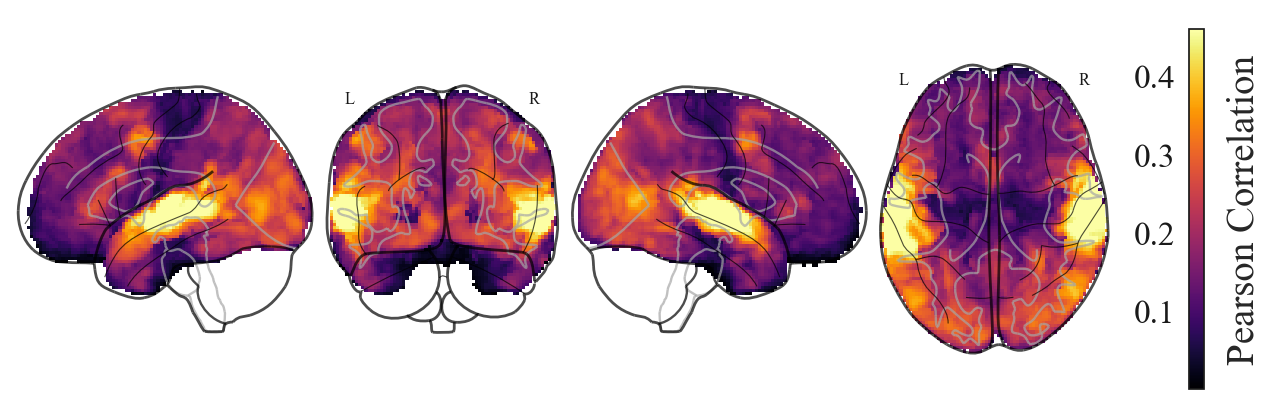

{'parcels':      parcel_id    mean_r  fisher_mean_r     sem_r  n_subjects  sub-01_r  \
 0            1  0.115830       0.115842  0.005953           4  0.130523   
 1            2  0.210742       0.211021  0.020672           4  0.245344   
 2            3  0.219876       0.221197  0.042692           4  0.255960   
 3            4  0.284631       0.286022  0.038636           4  0.308135   
 4            5  0.248878       0.250647  0.044018           4  0.221606   
 ..         ...       ...            ...       ...         ...       ...   
 995        996  0.162990       0.163308  0.024050           4  0.123368   
 996        997  0.236814       0.237080  0.018426           4  0.219941   
 997        998  0.159685       0.159808  0.015836           4  0.132165   
 998        999  0.154665       0.154727  0.011174           4  0.136188   
 999       1000  0.188022       0.188390  0.025316           4  0.128706   
 
      sub-02_r  sub-03_r  sub-05_r  
 0    0.106769  0.105551  0.120476  
 

In [20]:
group_results = {}

for readout_res in ("parcels", "voxels"):
    available = filter_accuracy_items(acc_items, readout_res=readout_res, split="test")
    if not available:
        continue
    print(f"\nOverall {readout_res} encoding accuracy")
    group_results[readout_res] = plot_overall_encoding_acc(
        acc_items,
        readout_res=readout_res,
        split="test",
        positive_only=True,
        cmap="inferno",
        reference_subject=1,
        shared_only=True,
        save=True,
        backbones="dino_whisper_llama",
        # backbones="videmae_wav2vec_deberta"
    )

group_results


## Plot Overall Accuracy By View

Render the overall parcels and voxels encoding accuracy maps separately for each brain view without colorbars, while keeping the current fixed positive scale.


Overall parcels encoding accuracy by view
saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/overall_parcels_encoding_acc_by_view/overall_parcels_l_dino_whisper_llama.pdf


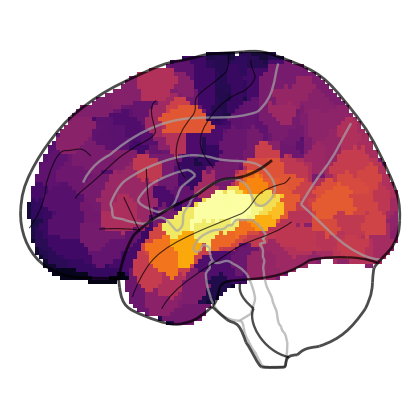

saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/overall_parcels_encoding_acc_by_view/overall_parcels_r_dino_whisper_llama.pdf


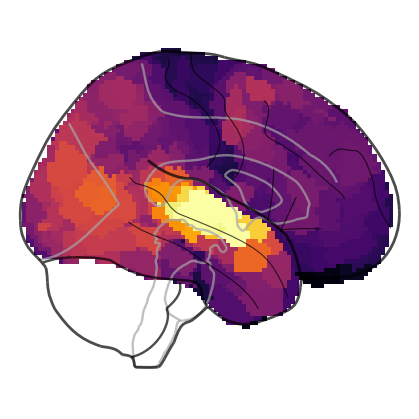

saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/overall_parcels_encoding_acc_by_view/overall_parcels_y_dino_whisper_llama.pdf


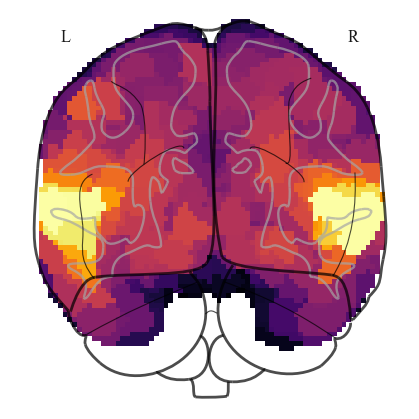

saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/overall_parcels_encoding_acc_by_view/overall_parcels_z_dino_whisper_llama.pdf


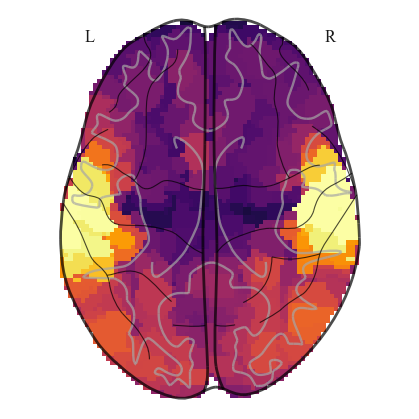


Overall voxels encoding accuracy by view
saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/overall_voxels_encoding_acc_by_view/overall_voxels_l_dino_whisper_llama.pdf


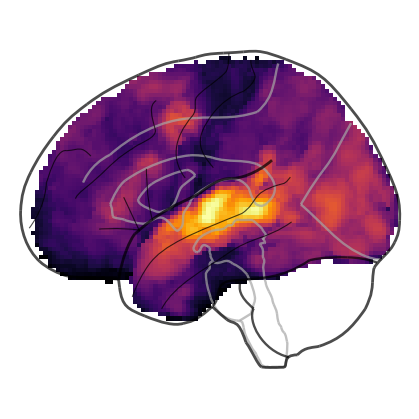

saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/overall_voxels_encoding_acc_by_view/overall_voxels_r_dino_whisper_llama.pdf


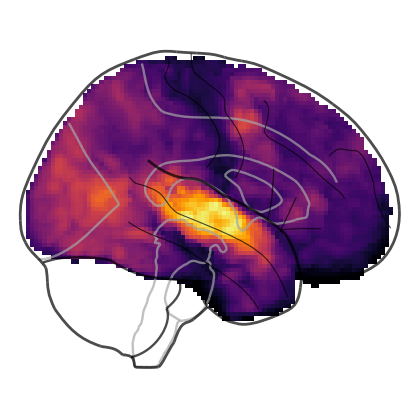

saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/overall_voxels_encoding_acc_by_view/overall_voxels_y_dino_whisper_llama.pdf


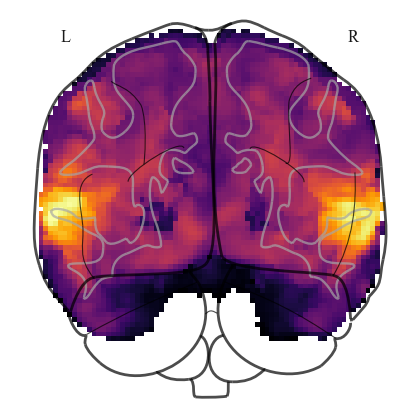

saved: /engram/nklab/pf2477/multimodal_encoder/notebooks/figures/encoding_acc/overall_voxels_encoding_acc_by_view/overall_voxels_z_dino_whisper_llama.pdf


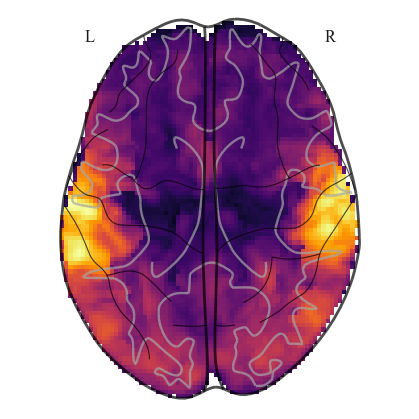

In [15]:
VIEW_MODES = ["l", "r", "y", "z"]
VIEW_TITLES = {"l": "left", "r": "right", "y": "inferior", "z": "superior"}
VIEW_SCALE = {"vmin": 0.0, "vmax": 0.6}


def plot_overall_accuracy_by_view(items, readout_res, split="test", save=False, backbones="dino_whisper_llama"):
    selected_items = filter_accuracy_items(items, readout_res=readout_res, split=split)
    if not selected_items:
        raise ValueError(f"No runs found for {readout_res=} and {split=}.")

    if readout_res == "parcels":
        values, _ = summarize_group_parcels(selected_items)
        subject = 1
    elif readout_res == "voxels":
        group_img, group_data, _ = summarize_group_voxels(selected_items, shared_only=True)
        values = group_data
        subject = selected_items[0]["subject"]
    else:
        raise ValueError(f"Unsupported readout_res: {readout_res}")

    for view in VIEW_MODES:
        if readout_res == "parcels":
            img = parcel_accuracy_to_img(values, subject)
        else:
            img = group_img

        fig = plt.figure(figsize=(4, 4), facecolor="white")
        plotting.plot_glass_brain(
            img,
            display_mode=view,
            cmap="inferno",
            colorbar=False,
            plot_abs=False,
            threshold=0.0,
            vmin=VIEW_SCALE["vmin"],
            vmax=VIEW_SCALE["vmax"],
            symmetric_cbar=False,
            black_bg=False,
            figure=fig,
        )
        for ax in fig.axes:
            ax.set_axis_off()
        fig.tight_layout()

        if save:
            out_dir = FIGURE_ROOT / f"overall_{readout_res}_encoding_acc_by_view"
            out_dir.mkdir(parents=True, exist_ok=True)
            out_file = out_dir / f"overall_{readout_res}_{view}_{backbones}.pdf"
            fig.savefig(str(out_file), dpi=300, bbox_inches="tight", facecolor="white", transparent=False)
            print("saved:", out_file)
        plt.show()

    return True


for readout_res in ("parcels", "voxels"):
    available = filter_accuracy_items(acc_items, readout_res=readout_res, split="test")
    if not available:
        continue
    print(f"\nOverall {readout_res} encoding accuracy by view")
    plot_overall_accuracy_by_view(
        acc_items,
        readout_res=readout_res,
        split="test",
        save=True,
        backbones="dino_whisper_llama",
    )
